# Neural Network Classification

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Layers import
from tensorflow.keras.layers import Dense

In [2]:
tf.__version__

'2.21.0'

In [3]:
# Dataset
from sklearn.datasets import make_circles

# make 1000 examples
n_samples = 1000

# create circles
X, y = make_circles(
    n_samples,
    noise=0.03,
    random_state=42
)

In [4]:
print("X Data: ", X)
print("Y Data: ", y[:10])

X Data:  [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 ...
 [-0.13690036 -0.81001183]
 [ 0.67036156 -0.76750154]
 [ 0.28105665  0.96382443]]
Y Data:  [1 1 1 1 0 1 1 1 1 0]


In [5]:
circle = pd.DataFrame({
    "X0": X[:,0],
    "X1": X[:,1],
    "label": y
})

circle

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


<Axes: xlabel='X0', ylabel='X1'>

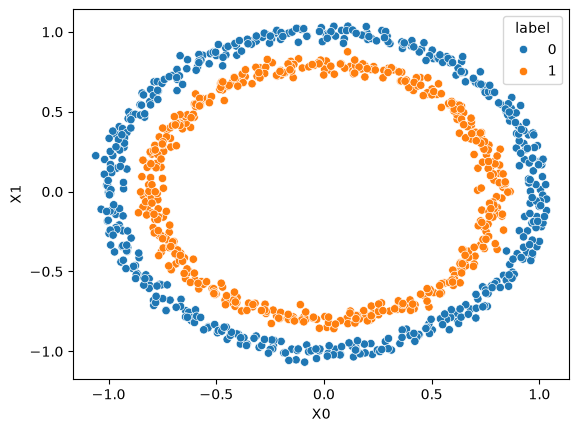

In [6]:
sns.scatterplot(
    data=circle,
    x="X0",
    y="X1",
    hue="label"
)


In [7]:
# seed
tf.random.set_seed(42)

# create the model
model = tf.keras.Sequential([
    Dense(100, activation="relu"),
    Dense(10, activation="relu"),
    Dense(1, activation="sigmoid"),
])

# compile the model
model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['mae']
)

# fit the model
history = model.fit(
    X, 
    y,
    epochs=100
)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.5009 - mae: 0.5009
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4960 - mae: 0.4960  
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4920 - mae: 0.4920 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4879 - mae: 0.4879
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4835 - mae: 0.4835
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4790 - mae: 0.4790
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4743 - mae: 0.4743
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4690 - mae: 0.4690
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4616 - mae: 0.4616
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4518 - mae: 0.4518
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4374 - mae: 0.4374
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4172 - mae: 0.4172
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━

<Axes: >

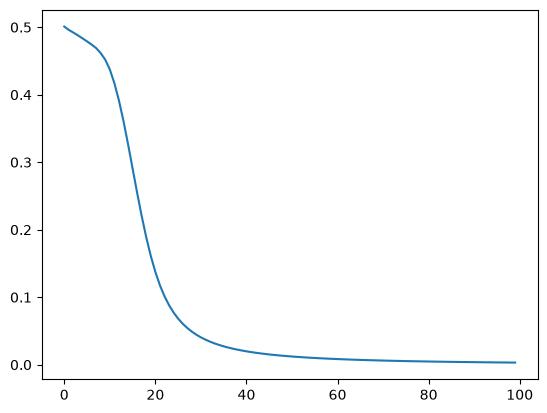

In [8]:
pd.DataFrame(history.history)["loss"].plot()

In [9]:
y_pred = model.predict(X)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


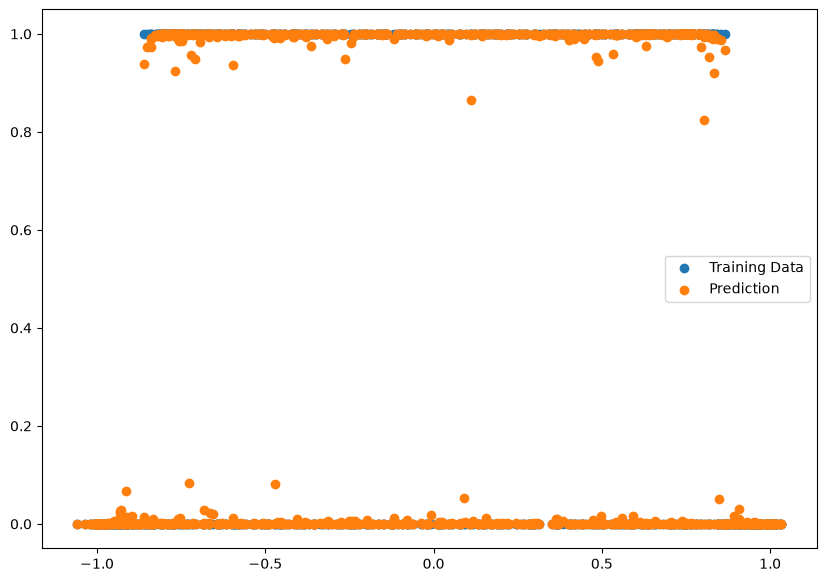

In [10]:
# plot the model prediction against our regression data
plt.figure(figsize=(10,7))
plt.scatter(X[:, 0],y,label="Training Data")
plt.scatter(X[:, 0],y_pred, label="Prediction")
plt.legend()
plt.show()

#### About meshgrid


XX: [[1 2 3 4]
 [1 2 3 4]
 [1 2 3 4]
 [1 2 3 4]]
YY: [[10 10 10 10]
 [20 20 20 20]
 [30 30 30 30]
 [40 40 40 40]]


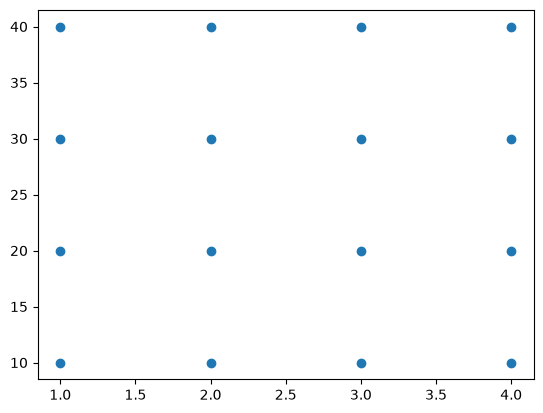

In [11]:
a = [1,2,3,4]
b = [10,20,30,40]

xx, yy = np.meshgrid(a,b)

print("XX:",xx)
print("YY:",yy)

plt.scatter(xx, yy)

In [12]:
def plot_decision_boundary(model,X,y):
  """
  Plots the decision boundary created by a model predicting on X.
  This function has been adapted from two phenomenal resources:
   1. CS231n - https://cs231n.github.io/neural-networks-case-study/
  """
  # define the axis boundaries of the plot and create a meshgrid
  x_min, x_max = X[:,0].min() - 0.1,  X[:,0].max() + 0.1
  y_min, y_max = X[:,1].min() - 0.1,  X[:,1].max() + 0.1
  xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
  )

  # Create X value ( we're going to make predicitons on these)
  x_in = np.c_[xx.ravel(), yy.ravel()] # stack 2D arrays together

  # Make predictions
  y_pred = model.predict(x_in)

  # Check for multi-class
  if model.output_shape[-1] > 1: # checks the final dimension of the model's output shape, if this is > (greater than) 1, it's multi-class
    print("doing multiclass classification...")
    # We have to reshape our predictions to get them ready for plotting
    y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
  else:
    print("doing binary classifcation...")
    y_pred = np.round(np.max(y_pred, axis=1)).reshape(xx.shape)

  # Plot decision boundary
  plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
  plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
doing binary classifcation...


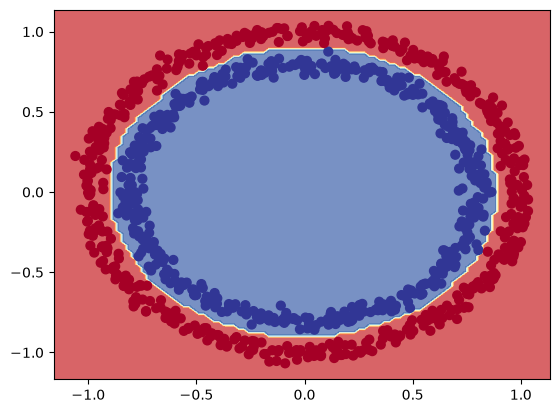

In [13]:
plot_decision_boundary(
    model=model,
    X=X,
    y=y)

# Activation Functions

In [14]:
A = tf.cast(tf.range(-10,10),tf.float32)

## Sigmoid

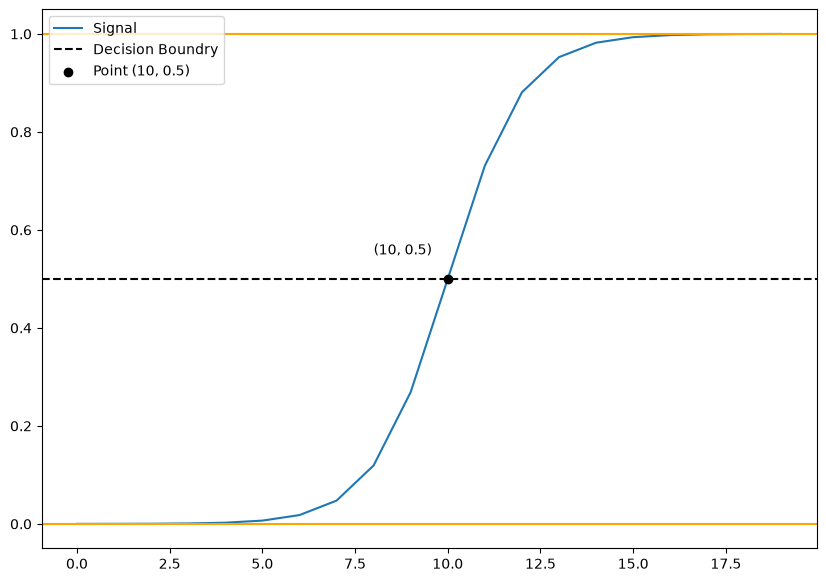

In [15]:
def sigmoid(value):
    return 1/(1 + tf.exp(-value))

sig = sigmoid(A)

plt.figure(figsize=(10,7))

# Plot your signal
plt.plot(sig, label="Signal")
plt.axhline(y=1, color="orange", linestyle="-")
plt.axhline(y=0.5, color="black", linestyle="--", label="Decision Boundry")
plt.axhline(y=0, color="orange", linestyle="-")
plt.scatter(10, 0.5, color="black", zorder=5, label = "Point (10, 0.5)")
plt.annotate(
    "(10, 0.5)",
    xy=(10, 0.5),
    xytext=(8, 0.55)  
)
plt.legend()
plt.show()


## Relu

In [16]:
def relu(value):
    return tf.maximum(0, value)

relu(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6.,
       7., 8., 9.], dtype=float32)>

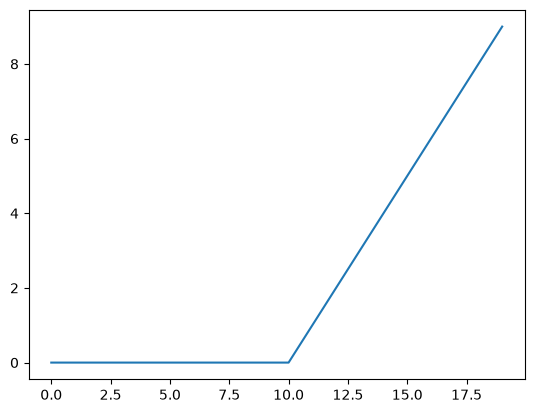

In [17]:
plt.plot(relu(A))

# Finding Best Learing Rate

In [18]:
circle.head()

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


In [19]:
X = circle.drop("label", axis=1)
y = circle['label']

In [20]:
# Split into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.3)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((700, 2), (300, 2), (700,), (300,))

In [21]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_2 =  tf.keras.Sequential([
    tf.keras.layers.Dense(10,activation='relu'),
    tf.keras.layers.Dense(5,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid'),
])

# 2. Compile the model
model_2.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy'])

# 3. Creating the callback
lr_schedular = tf.keras.callbacks.LearningRateScheduler(
    lambda epochs: 1e-4 * 10**(epochs/20)
)

# 4. fit the model (passing lr_scheduler callback)
history_1 = model_2.fit(
    X_train,y_train,epochs=100,
    callbacks=[lr_schedular]
)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4914 - loss: 0.6890 - learning_rate: 1.0000e-04
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4914 - loss: 0.6889 - learning_rate: 1.1220e-04
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4914 - loss: 0.6888 - learning_rate: 1.2589e-04
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4914 - loss: 0.6887 - learning_rate: 1.4125e-04
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4914 - loss: 0.6886 - learning_rate: 1.5849e-04
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4914 - loss: 0.6884 - learning_rate: 1.7783e-04
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4914 - loss: 0.6883 - learning_rate: 1.9953e-04
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4914 - loss: 0.6881 - learning_rate: 2.2387e-04
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4914 - loss: 0.6879 - learning_

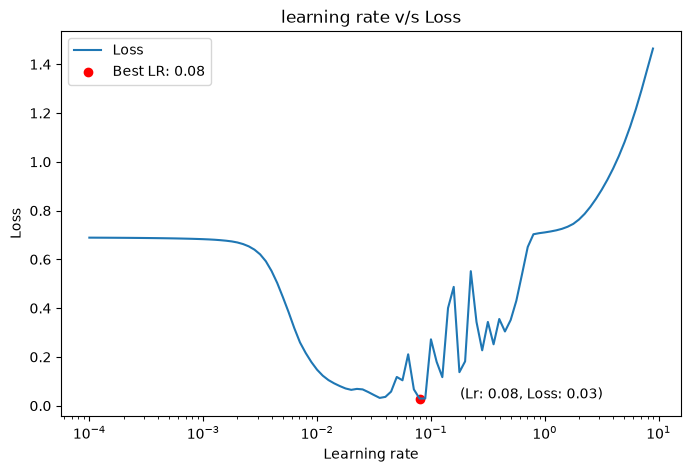

In [68]:
lrs = 1e-4 * (10**(tf.range(100)/20)) 
losses = history_1.history['loss'] 

# Finding the lowest loss and position of the learning rate 
min_idx = np.argmin(losses) 
min_lr = lrs[min_idx] 
min_loss = losses[min_idx] 

plt.figure(figsize=(8,5)) 
plt.semilogx(lrs,history_1.history['loss'], label="Loss") 
plt.scatter(
    min_lr, 
    min_loss, 
    label=f"Best LR: {np.round(min_lr, 2)}", color="red",
)

# Annotation
min_lr_label = np.round(min_lr, 2)
min_loss_label = np.round(min_loss, 2)
plt.annotate(
    f"(Lr: {min_lr_label}, Loss: {min_loss_label})",
    xy=(min_lr_label, min_loss_label),
    xytext= (min_lr_label + 1e-1, min_loss_label)
)
plt.xlabel("Learning rate") 
plt.ylabel("Loss") 
plt.title("learning rate v/s Loss")
plt.legend()
plt.show()